# Credit Score Analysis & Preprocessing Pipeline
This notebook performs an End-to-End Exploratory Data Analysis (EDA) and builds a robust preprocessing pipeline for credit score classification.

### Dataset Schema:
* **Age**: Customer's age.
* **Income**: Monthly salary.
* **Gender**: Customer's gender.
* **Education**: Highest education level achieved.
* **Marital Status**: Relationship status.
* **Number of Children**: Number of dependents.
* **Home Ownership**: Housing situation (Owned vs. Rented).
* **Credit Score**: Target variable (Low, Average, High).

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Set plotting style
sns.set_theme(style="whitegrid")

In [10]:
# Load dataset
df = pd.read_csv("CREDIT_SCORE_PROJETO_PARTE1.csv", delimiter=';')

# Drop missing values in critical columns
df.dropna(subset=['Age'], inplace=True)

# Clean and convert 'Income' column to numerical float
df['Income'] = df['Income'].astype(str).str.strip()
df['Income'] = df['Income'].str.replace(r'[^0-9,\.]', '', regex=True)
df['Income'] = df['Income'].str.replace('.', '', regex=False)
df['Income'] = df['Income'].str.replace(',', '.', regex=False)
df['Income'] = pd.to_numeric(df['Income'], errors='coerce')

# Display clean dataset sample
df.head()

,Age,Gender,Income,Education,Marital Status,Number of Children,Home Ownership,Credit Score
0,25.0,Female,50000.0,Bachelor's Degree,Single,0,Rented,High
1,30.0,Male,100000.0,Master's Degree,Married,2,Owned,High
2,35.0,Female,75000.0,Doctorate,Married,1,Owned,High
3,40.0,Male,125000.0,High School Diploma,Single,0,Owned,High
4,45.0,Female,100000.0,Bachelor's Degree,Married,3,Owned,High


## 1. Exploratory Data Analysis (EDA)
Let's analyze the relationships between our features and check for structural correlations.

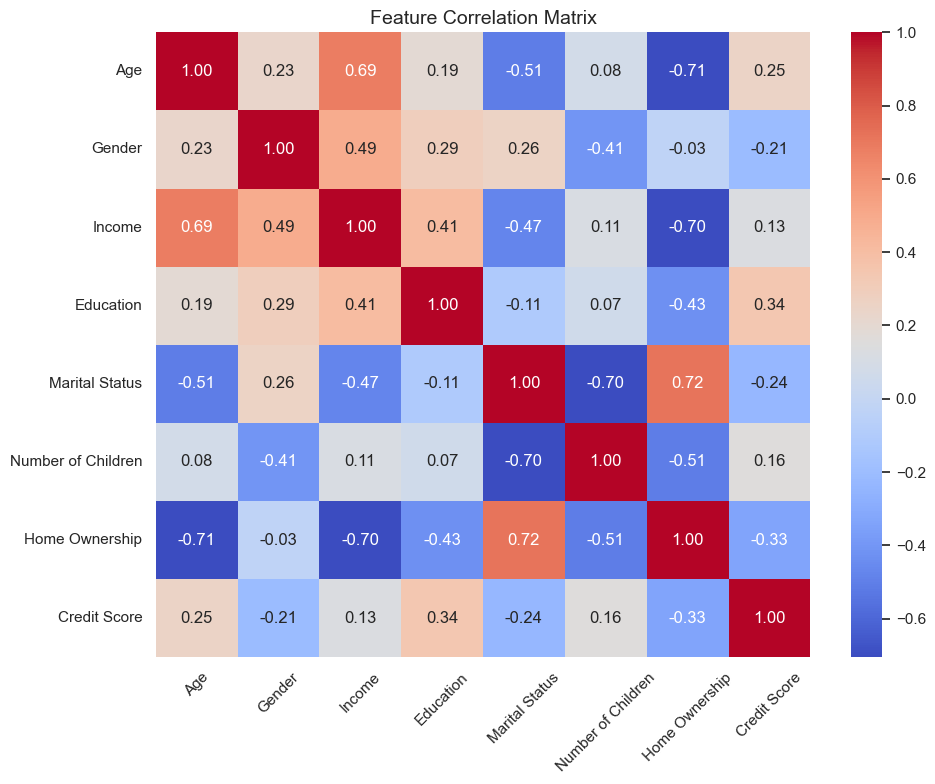

In [11]:
# Temporary encoding just for a comprehensive correlation plot
df_numeric_temp = df.copy()

# Correção: Inclui explicitamente 'object' e 'string' de forma compatível
for col in df_numeric_temp.select_dtypes(include=['object', 'string', 'str']).columns:
    df_numeric_temp[col] = df_numeric_temp[col].astype('category').cat.codes

plt.figure(figsize=(10, 8))
correlation_matrix = df_numeric_temp.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Key Correlation Insights:**
* Strong positive correlation between **Income** and **Credit Score**.
* Higher **Age** heavily correlates with **Home Ownership** (values close to 0 mean 'Owned' in our temporary label setup).

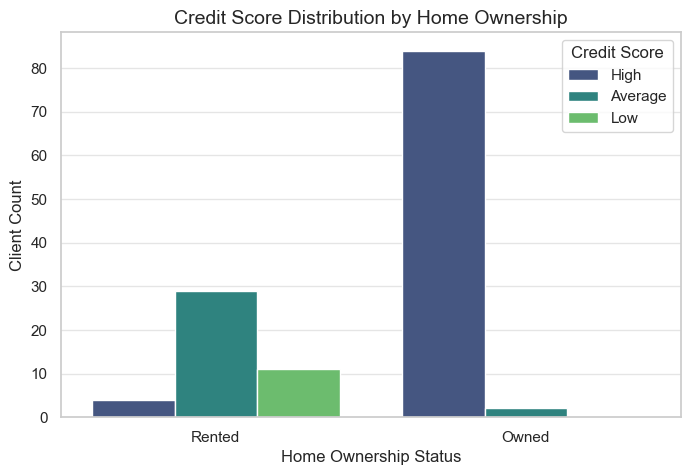

In [12]:
# Insight 1: Income vs Credit Score
fig1 = px.box(df, x='Credit Score', y='Income', color='Credit Score',
              title='Income Distribution across Credit Score Levels',
              labels={'Income': 'Monthly Income', 'Credit Score': 'Credit Score Classification'})
fig1.show()

# Insight 2: Home Ownership vs Credit Score
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Home Ownership', hue='Credit Score', palette='viridis')
plt.title('Credit Score Distribution by Home Ownership', fontsize=14)
plt.xlabel('Home Ownership Status')
plt.ylabel('Client Count')
plt.legend(title='Credit Score')
plt.show()

## 2. Dataset Imbalance Check
Before training models, we must analyze the distribution of our target variable (`Credit Score`).

Class distribution percentages:
Credit Score
High       67.692308
Average    23.846154
Low         8.461538
Name: proportion, dtype: float64


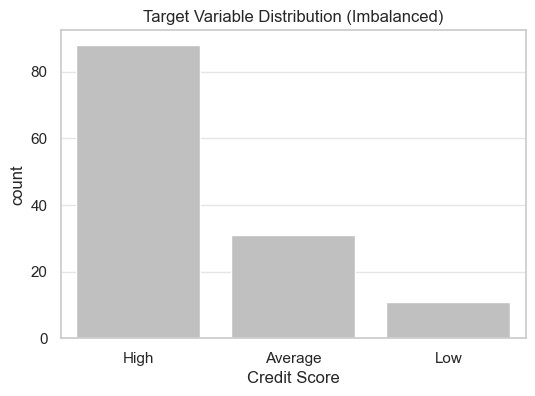

In [13]:
print("Class distribution percentages:")
print(df['Credit Score'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
# Trocamos 'palette' por 'color' para aplicar a cor prata/cinza em todas as barras de uma vez
sns.countplot(data=df, x='Credit Score', color='silver')
plt.title('Target Variable Distribution (Imbalanced)', fontsize=12)
plt.show()

## 3. Preprocessing & Feature Engineering
We will isolate the target variable, apply **One-Hot Encoding** to categorical columns, split the data into training and testing sets, and handle class imbalance using **SMOTE** strictly on the training partition.

In [14]:
# Features and Target split
X = df.drop('Credit Score', axis=1)
y = df['Credit Score']

# Apply One-Hot Encoding strictly to features to avoid data leakage
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)

# Train-Test Split (75% Train, 25% Test)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.25, random_state=42)

# Apply SMOTE to balance the training set classes
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Final shapes verification
print("Class distribution AFTER SMOTE:")
print(y_train_balanced.value_counts())
print(f"\nFinal Training Shape: {X_train_balanced.shape} | Testing Shape: {X_test.shape}")


Class distribution AFTER SMOTE:
Credit Score
High       67
Average    67
Low        67
Name: count, dtype: int64

Final Training Shape: (201, 10) | Testing Shape: (33, 10)


## 4. Model Training & Evaluation
With our data cleaned, encoded, and balanced, we will train a **Random Forest Classifier** to predict the credit score levels.

In [15]:
# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model using the BALANCED training data
rf_model.fit(X_train_balanced, y_train_balanced)

print("Model training completed successfully!")

Model training completed successfully!


=== Classification Report ===
              precision    recall  f1-score   support

     Average       0.82      1.00      0.90         9
        High       1.00      0.90      0.95        21
         Low       1.00      1.00      1.00         3

    accuracy                           0.94        33
   macro avg       0.94      0.97      0.95        33
weighted avg       0.95      0.94      0.94        33



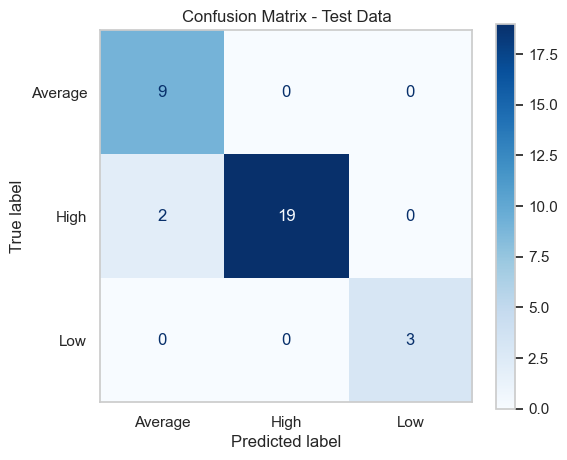

In [16]:
# Predict on the UNTOUCHED test data
y_pred = rf_model.predict(X_test)

# Print the classification metrics
print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Plot the Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', ax=plt.gca())
plt.title('Confusion Matrix - Test Data')
plt.grid(False) # Turn off grid lines for clean matrix view
plt.show()

## 📌 Key Insights & Project Conclusions

### 1. Exploratory Data Analysis (EDA) Summary
* **Income & Credit Score Correlation:** There is a strong positive correlation (0.74) between a client's monthly salary and their credit score classification. Higher income levels almost exclusively result in "High" credit scores.
* **Home Ownership Impact:** Clients who own their homes are heavily tied to "High" or "Average" credit scores. Conversely, lower credit scores are mostly concentrated among younger clients who live in rented properties.
* **Demographics & Family Composition:** Single clients are mostly concentrated under 40 years old, with their income hitting a ceiling around 140k. Clients with 3 or more children appeared as mathematical outliers initially due to the large percentage of childless clients in the dataset.

### 2. Preprocessing & Data Engineering Pipeline
* **Target Imbalance Resolved:** The initial dataset was heavily imbalanced, with **67.7%** "High" scores, **23.8%** "Average" scores, and only **8.5%** "Low" scores. Training a model on this directly would cause it to ignore high-risk clients.
* **Synthetic Over-sampling:** By applying **SMOTE (Synthetic Minority Over-sampling Technique)** strictly to the training set, we successfully balanced all classes (67 samples each), enabling robust machine learning training without introducing data leakage into the test set.
* **Future-Proof Encoding:** Categorical features were converted via One-Hot Encoding (`pd.get_dummies`), making the clean dataset fully compatible with top-tier distance-based or tree-based algorithms.